# 이탈 지점 탐색 — 어디서 나가는가

**작성** 2026-09-03 · **원천** BigQuery GA4 export (`analytics_547127440.events_*`)

가설을 세우기 전에 데이터가 뭐라고 하는지부터 봤다.
처음 물었던 건 "유저가 어느 행동을 하다 나가는가"였다.

**결론부터**: 특정 행동에서 나가는 게 아니다. 게임에 들어오지 못한 채로 끝난다.

규모부터 보면 8/15 유입 뒤 WAU 가 115 → 27 로 내려앉았다. 이 노트북은 그 사람들이
어디서 사라지는지를 따라간다.

이 노트북은 결론을 내는 자리가 아니라 관측을 남기는 자리다.
모델은 만들지 않았다.

In [1]:
import warnings
# BigQuery Storage 가속 모듈이 없다는 경고 — 결과가 수백 행이라 REST 로 충분하다.
# 셀마다 끼면 읽기 나쁘니 끈다.
warnings.filterwarnings("ignore", message=".*BigQuery Storage.*")

from calm_ml import bq, report as R
import pandas as pd

R.setup()
pd.set_option("display.max_rows", 40)

## 1. 얼마나 오고, 얼마나 남는가

이탈 지점을 찾기 전에 규모부터 본다. 사람 단위는 `user_pseudo_id`(브라우저)로 잡는다 —
`user_id` 는 익명 uid 가 세션마다 재발급돼 기기당 3.25개로 부풀기 때문이다.

In [2]:
au = bq.read_sql(f"""
WITH ev AS (
  SELECT user_pseudo_id AS device,
         DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS d
  FROM `calm-forest.analytics_547127440.events_*`
),
-- 날짜 축을 먼저 만든다. 활동 없는 날도 빠지지 않게.
days AS (
  SELECT d FROM UNNEST(GENERATE_DATE_ARRAY(
    (SELECT MIN(d) FROM ev), (SELECT MAX(d) FROM ev))) AS d
)
SELECT k.d,
  COUNT(DISTINCT IF(e.d = k.d, e.device, NULL))                                    AS dau,
  COUNT(DISTINCT IF(e.d BETWEEN DATE_SUB(k.d, INTERVAL  6 DAY) AND k.d, e.device, NULL)) AS wau,
  COUNT(DISTINCT IF(e.d BETWEEN DATE_SUB(k.d, INTERVAL 29 DAY) AND k.d, e.device, NULL)) AS mau
FROM days k LEFT JOIN ev e ON e.d <= k.d
GROUP BY 1 ORDER BY 1
""")
au["d"] = pd.to_datetime(au.d)
print(f"기간 {au.d.min():%Y-%m-%d} ~ {au.d.max():%Y-%m-%d} ({len(au)}일)")
for c in ["dau", "wau", "mau"]:
    print(f"{c.upper():4s} 최고 {au[c].max():>4d}  최근 {au[c].iloc[-1]:>4d}")
print(f"\nDAU/MAU = {au.dau.iloc[-1]}/{au.mau.iloc[-1]} = {au.dau.iloc[-1]/au.mau.iloc[-1]:.1%}")

기간 2026-07-27 ~ 2026-09-03 (39일)
DAU  최고   47  최근    6
WAU  최고  115  최근   29
MAU  최고  226  최근  220

DAU/MAU = 6/220 = 2.7%


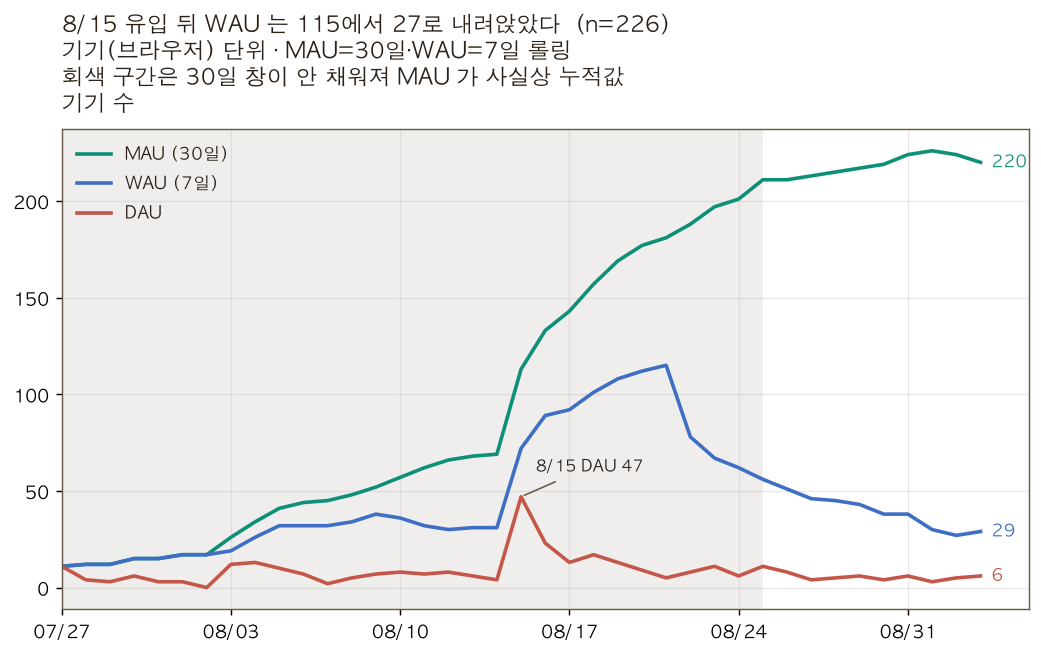

In [3]:
import matplotlib.dates as mdates

n = int(au.mau.max())
fig, ax = R.new("8/15 유입 뒤 WAU 는 115에서 27로 내려앉았다", n=n,
                sub="기기(브라우저) 단위 · MAU=30일·WAU=7일 롤링\n"
                    "회색 구간은 30일 창이 안 채워져 MAU 가 사실상 누적값",
                ylab="기기 수", figsize=(9.6, 4.8))

# 30일 창이 채워지기 전 — 여기 MAU 를 MAU 로 읽으면 안 된다
ax.axvspan(au.d.min(), au.d.min() + pd.Timedelta(days=29), color=R.MUTED, alpha=0.10, lw=0)

for col, lab, c in [("mau", "MAU (30일)", R.PALETTE[2]),
                    ("wau", "WAU (7일)",  R.PALETTE[1]),
                    ("dau", "DAU",        R.PALETTE[0])]:
    ax.plot(au.d, au[col], color=c, lw=2.0, label=lab)
    ax.annotate(f"{int(au[col].iloc[-1])}", (au.d.iloc[-1], au[col].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", color=c, va="center", fontsize=9.5)

peak = au.loc[au.dau.idxmax()]
ax.annotate(f"8/15 DAU {int(peak.dau)}", (peak.d, peak.dau), xytext=(8, 14),
            textcoords="offset points", fontsize=9, color=R.INK,
            arrowprops=dict(arrowstyle="-", color=R.MUTED, lw=0.9))

ax.legend(frameon=False, loc="upper left", fontsize=9.5)
ax.set_xlim(au.d.min(), au.d.max() + pd.Timedelta(days=2))
# 날짜를 전부 찍으면 라벨이 겹쳐 못 읽는다 — 주 단위 + 월/일
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
R.show(R.save(fig, ax, "g_dau_wau_mau"))

### 읽은 것

8/15 에 유입이 한 번 있었고, 그 뒤로 계속 빠지고 있다.

| | 최고 | 최근(9/2) |
|---|---|---|
| DAU | 47 (8/15) | **5** |
| WAU | 115 (8/21) | **27** |
| MAU | 226 (9/1) | 224 |

**MAU 만 평평한 건 착시다.** 30일 창이라 8/15 유입이 아직 창 안에 있을 뿐이고,
9월 중순이면 그 사람들이 빠져나가면서 MAU 도 따라 내려간다.

**DAU/MAU = 2.2%.** 200명 중 하루에 한 번 오는 사람이 4~5명이다.

이 그림이 이 노트북의 질문을 만든다 — **들어오긴 하는데 왜 안 남는가.**
아래부터는 그 사람들이 어디서 사라지는지 본다.

8/15 에 온 사람들이 누구였고 뭘 했는지는 바로 다음 절에서 본다.

## 2. 8/15 에 온 사람들은 누구였나

DAU 가 47 로 한 번 튄 날이다. 그날 활동한 기기를 코호트로 잡고
**누구였는지 · 뭘 했는지 · 다시 왔는지**를 본다.

In [4]:
EX15 = ("'first_visit','session_start','page_view','scroll','user_engagement',"
        "'session_time','session_summary','weather_day','weather_event','econ_tx','login'")

coh = bq.read_sql(f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name,
         DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS d
  FROM `calm-forest.analytics_547127440.events_*`
),
fd  AS (SELECT device, MIN(d) AS d0 FROM ev GROUP BY 1),
c15 AS (SELECT DISTINCT device FROM ev WHERE d = '2026-08-15')
SELECT c.device,
  f.d0 = '2026-08-15' AS is_new,
  (SELECT COUNT(*) FROM ev e
     WHERE e.device = c.device AND e.d = '2026-08-15'
       AND e.event_name NOT IN ({EX15}) AND e.event_name NOT LIKE 'tutorial%') AS acts,
  -- 8/15 이후 다시 온 날이 있는지. 관측이 18일 남아 있어 이 값은 믿을 만하다
  (SELECT COUNT(DISTINCT e.d) FROM ev e
     WHERE e.device = c.device AND e.d > '2026-08-15') AS days_after
FROM c15 c JOIN fd f USING (device)
""")
print(f"8/15 활동 기기 {len(coh)}대 · 신규 {int(coh.is_new.sum())}대 ({coh.is_new.mean():.0%})")
print(f"그날 행동 0    {int((coh.acts == 0).sum())}대 ({(coh.acts == 0).mean():.0%})")
print(f"이후 재방문    {int((coh.days_after > 0).sum())}대 ({(coh.days_after > 0).mean():.0%})")

8/15 활동 기기 47대 · 신규 44대 (94%)
그날 행동 0    35대 (74%)
이후 재방문    3대 (6%)


In [5]:
src = bq.read_sql("""
WITH c15 AS (SELECT DISTINCT user_pseudo_id AS dev
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE DATE(TIMESTAMP_MICROS(event_timestamp),'Asia/Seoul') = '2026-08-15')
SELECT COALESCE(e.traffic_source.source, '(없음)') AS src,
       COALESCE(e.traffic_source.medium, '(없음)') AS medium,
       COUNT(DISTINCT e.user_pseudo_id) AS devices
FROM `calm-forest.analytics_547127440.events_*` e JOIN c15 c ON c.dev = e.user_pseudo_id
GROUP BY 1, 2 ORDER BY devices DESC
""")
print("유입 출처"); print(src.to_string(index=False))

# CTE 별칭을 device 로 두면 GA4 의 device 구조체와 충돌한다(실측) → dev 로
geo = bq.read_sql("""
WITH c15 AS (SELECT DISTINCT user_pseudo_id AS dev
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE DATE(TIMESTAMP_MICROS(event_timestamp),'Asia/Seoul') = '2026-08-15')
SELECT e.geo.country AS country, COUNT(DISTINCT e.user_pseudo_id) AS devices
FROM `calm-forest.analytics_547127440.events_*` e JOIN c15 c ON c.dev = e.user_pseudo_id
GROUP BY 1 ORDER BY devices DESC
""")
print("\n국가"); print(geo.to_string(index=False))

유입 출처
            src   medium  devices
       (direct)   (none)       43
           bing  organic        1
           t.co referral        1
l.instagram.com referral        1
   facebook.com referral        1



국가
      country  devices
United States       32
  South Korea       12
         Iran        1
       Poland        1
      Ireland        1


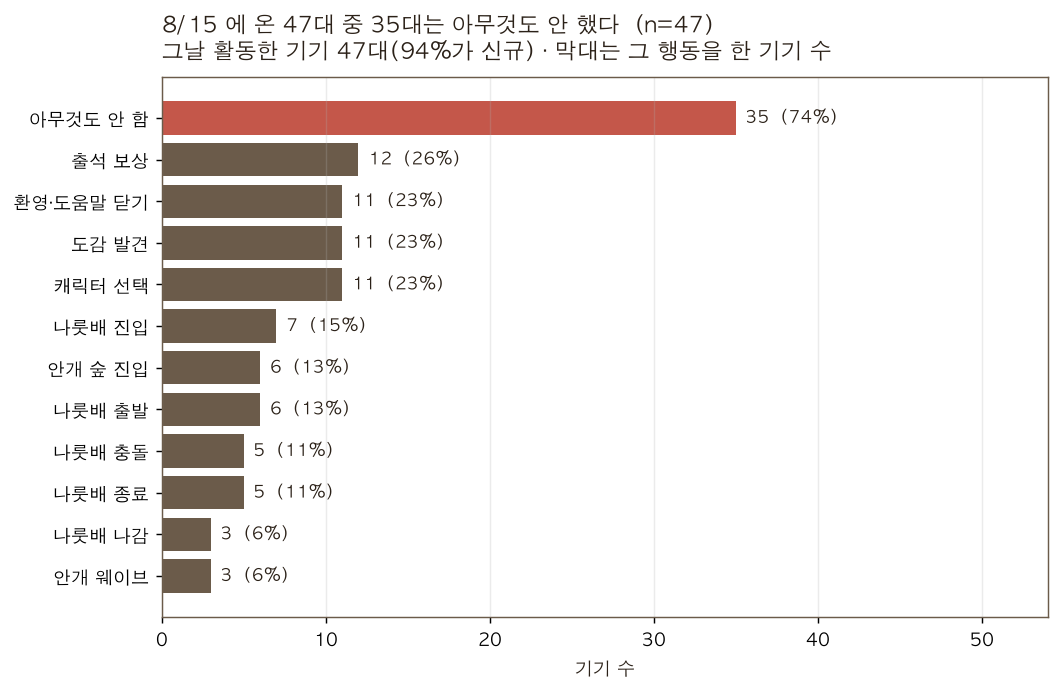

In [6]:
acts15 = bq.read_sql(f"""
WITH c15 AS (SELECT DISTINCT user_pseudo_id AS dev
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE DATE(TIMESTAMP_MICROS(event_timestamp),'Asia/Seoul') = '2026-08-15')
SELECT e.event_name, COUNT(DISTINCT e.user_pseudo_id) AS devices
FROM `calm-forest.analytics_547127440.events_*` e JOIN c15 c ON c.dev = e.user_pseudo_id
WHERE DATE(TIMESTAMP_MICROS(e.event_timestamp),'Asia/Seoul') = '2026-08-15'
  AND e.event_name NOT IN ({EX15})
GROUP BY 1 ORDER BY devices DESC
""")

KO = {"daily_bonus":"출석 보상","tutorial_skip":"환영·도움말 닫기","dex_discover":"도감 발견",
      "character_select":"캐릭터 선택","boat_enter":"나룻배 진입","boat_start":"나룻배 출발",
      "mist_enter":"안개 숲 진입","boat_end":"나룻배 종료","boat_hit":"나룻배 충돌",
      "mist_wave":"안개 웨이브","mist_end":"안개 종료","boat_exit":"나룻배 나감",
      "mist_exit":"안개 나감","nickname_set":"닉네임 설정","mist_purify_start":"안개 정화 시작",
      "mist_soothe_miss":"안개 리듬 실패","mist_soothe":"안개 달래기","photo_capture":"사진 찍기",
      "intro_start":"인트로 시작","intro_skip":"인트로 건너뛰기","story_chapter_start":"이야기 시작",
      "chop_tree":"나무 베기","first_chop":"첫 벌목","npc_talk":"NPC 대화","dex_open":"도감 열기"}
top = acts15.head(11).copy()
missing = [e for e in top.event_name if e not in KO]
if missing:
    print("⚠️ 한글 라벨 없음:", missing)   # 순위가 동점으로 흔들리므로 매번 확인한다
top["label"] = top.event_name.map(lambda s: KO.get(s, s))

nothing = int((coh.acts == 0).sum())
rows = [("아무것도 안 함", nothing)] + list(zip(top.label, top.devices))
n = len(coh)
fig, ax = R.new(f"8/15 에 온 {n}대 중 {nothing}대는 아무것도 안 했다", n=n,
                sub=f"그날 활동한 기기 {n}대({coh.is_new.mean():.0%}가 신규) · 막대는 그 행동을 한 기기 수",
                figsize=(8.8, 5.4))
y = range(len(rows))
ax.barh(list(y), [v for _, v in rows], color=[R.PALETTE[0]] + [R.MUTED] * (len(rows) - 1))
ax.set_yticks(list(y)); ax.set_yticklabels([l for l, _ in rows], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("기기 수")
ax.set_xlim(0, n * 1.15)
ax.grid(axis="y", visible=False)
for i, (_, v) in enumerate(rows):
    ax.text(v + 0.6, i, f"{v}  ({v/n:.0%})", va="center", fontsize=9.5, color=R.INK)
R.show(R.save(fig, ax, "g_aug15_cohort", zero_base=False))

### 읽은 것

**튄 게 아니라 스쳐 지나갔다.**

| | |
|---|---|
| 8/15 활동 기기 | 47 |
| 신규 | **44 (94%)** |
| 그날 행동 0 | **35 (74%)** |
| 이후 재방문 | **3 (6%)** |

전체 이탈 기기의 무행동 비율이 58% 인데 이 코호트는 **74%** 로 더 나쁘다.

**유입은 `(direct)` 43대**에 facebook · instagram · t.co · bing 이 한 대씩.
국가는 **미국 32대(68%)**, 한국 12대, 나머지 셋.
소셜 공유인데 리퍼러가 유실된 모양으로 보이지만 — 인앱 브라우저가 리퍼러를 지우는 경우가 흔하다 —
**추론이지 확정이 아니다.**

**뭔가 한 12대**는 출석 보상 12 → 캐릭터 선택·도감·환영 닫기 각 11 →
**나룻배 7·6·5·5 · 안개 숲 6·3** 으로 갔다. 벌목·농사가 아니라 **미니게임 직행**이다.
평소 게스트가 도감·출석 위주인 것과 다른 패턴이다.

### 이 숫자로 말할 수 없는 것

- **`(direct)` 43대의 정체를 모른다.** 리퍼러 유실인지 진짜 직접 입력인지 GA4 로는 안 갈린다.
- **미국 68% 가 봇인지 사람인지 안 갈린다.** i18n 작업 때 "미국 유저 45명 평균 체류 1초" 가
  나온 적이 있는데 같은 성격일 수 있다.
- **미니게임 직행 12대는 표본이 작다.** 나룻배 7 · 안개 6 이라 취향을 논할 수 없다.
- **8/15 에 무엇을 했는지(공유·배포)는 데이터에 없다.** 사람이 기억하는 것이 답이다.
- 재방문 3대는 관측이 18일 남아 있어 이 값만은 믿을 만하다.

## 이탈을 어떻게 셌나

두 가지를 먼저 정했다.

**이탈** — 마지막 흔적 이후 3일 넘게 안 돌아온 기기. 돌아올 기회를 주고도 안 온 경우만 센다.

**행동** — GA4 자동 수집 이벤트(`first_visit`·`session_start`·`page_view`·`scroll`·`user_engagement`)를 뺀다.
게임이 스스로 찍는 `session_time`·`session_summary`·`weather_day`도 사람이 한 게 아니라 뺐다.
`econ_tx`는 다른 행동에 딸려 나가는 원장 기록이라 중복이 되므로 역시 제외.

사람 단위 키는 `user_pseudo_id`를 쓴다. `user_id`는 익명 세션마다 새로 발급돼서 기기 수가 부풀려진다.

In [7]:
EXCLUDE = """'first_visit','session_start','page_view','scroll','user_engagement',
              'session_time','session_summary','weather_day','weather_event','econ_tx'"""

Q_LAST_ACTION = f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name,
         TIMESTAMP_MICROS(event_timestamp) AS ts
  FROM `calm-forest.analytics_547127440.events_*`
),
bounds AS (SELECT MAX(ts) AS data_end FROM ev),
dev AS (SELECT device, MAX(ts) AS last_seen FROM ev GROUP BY 1),

-- 이탈: 마지막 흔적 후 3일간 안 돌아온 기기
churned AS (
  SELECT d.device FROM dev d, bounds b
  WHERE d.last_seen < TIMESTAMP_SUB(b.data_end, INTERVAL 3 DAY)
),

-- 기기별 '마지막으로 한 행동' 1건
acts AS (
  SELECT device, event_name,
         ROW_NUMBER() OVER (PARTITION BY device ORDER BY ts DESC) AS rn
  FROM ev
  WHERE event_name NOT IN ({EXCLUDE})
)
SELECT COALESCE(a.event_name, '(활동 없음)') AS last_action,
       COUNT(*) AS devices
FROM churned c
LEFT JOIN acts a ON a.device = c.device AND a.rn = 1
GROUP BY 1 ORDER BY devices DESC
"""

last_action = bq.read_sql(Q_LAST_ACTION)
print("이탈 기기", last_action.devices.sum(), "대")
last_action.head(10)

이탈 기기 236 대


,last_action,devices
0,(활동 없음),136
1,login,33
2,chop_tree,6
3,npc_talk,6
4,dex_discover,4
5,water_crop,4
6,zone_enter,4
7,tutorial_skip,4
8,fishing_cast,4
9,tutorial_step,3


## 3. 마지막으로 한 행동

230대 중 133대가 게임 행동을 하나도 남기지 않았다. 32대는 마지막 흔적이 `login`이다.
나머지 65대는 20여 종에 흩어져 있고, 종당 1~6대라 이야기가 안 된다.

`login`이 뭘 뜻하는지는 뒤에서 다시 본다. 처음엔 "로그인만 하고 끝"으로 읽었는데 틀렸다.

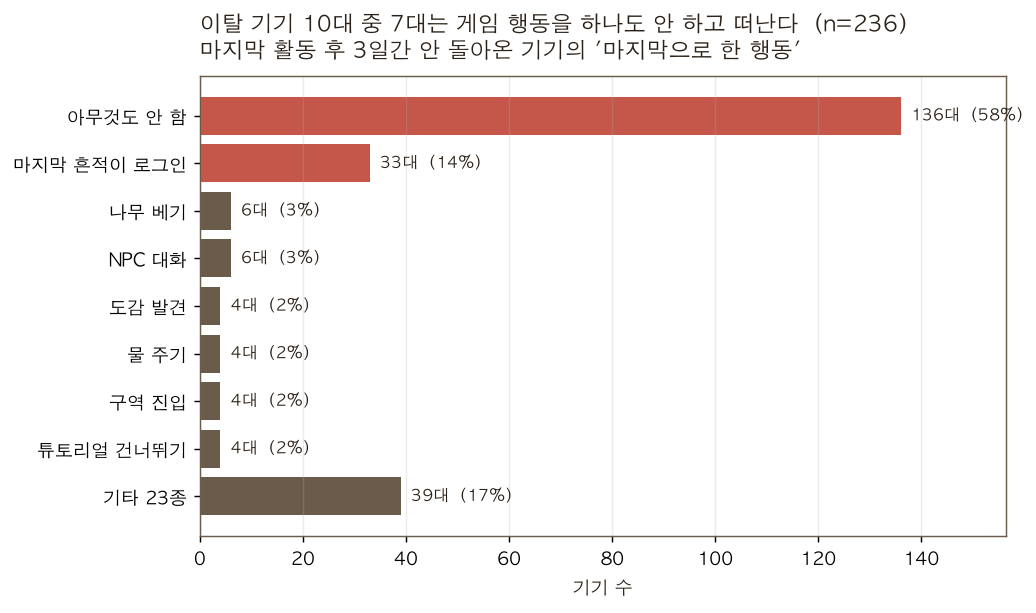

In [8]:
TOP = 8
top, tail = last_action.head(TOP), last_action.iloc[TOP:]
plot = pd.concat([top, pd.DataFrame(
    [{"last_action": f"기타 {len(tail)}종", "devices": tail.devices.sum()}])])

# 이벤트 이름 그대로 두면 비개발자가 못 읽는다
KO = {"(활동 없음)": "아무것도 안 함", "login": "마지막 흔적이 로그인",
      "npc_talk": "NPC 대화", "chop_tree": "나무 베기", "fishing_cast": "낚시 던지기",
      "zone_enter": "구역 진입", "tutorial_skip": "튜토리얼 건너뛰기",
      "dex_discover": "도감 발견", "water_crop": "물 주기"}
plot["label"] = plot.last_action.map(lambda s: KO.get(s, s))

n = int(last_action.devices.sum())
fig, ax = R.new("이탈 기기 10대 중 7대는 게임 행동을 하나도 안 하고 떠난다", n=n,
                sub="마지막 활동 후 3일간 안 돌아온 기기의 '마지막으로 한 행동'",
                figsize=(8, 4.6))
# 상위 2개가 이야기의 전부 — 나머지는 흐리게
colors = [R.PALETTE[0], R.PALETTE[0]] + [R.MUTED] * (len(plot) - 2)
y = range(len(plot))
ax.barh(list(y), plot.devices, color=colors)
ax.set_yticks(list(y)); ax.set_yticklabels(plot.label)
ax.invert_yaxis()
ax.set_xlabel("기기 수")
ax.set_xlim(0, plot.devices.max() * 1.15)
ax.grid(axis="y", visible=False)
for i, v in enumerate(plot.devices):
    ax.text(v + 2, i, f"{v}대  ({v/n:.0%})", va="center", fontsize=9, color=R.INK)
R.show(R.save(fig, ax, "g_last_action", zero_base=False))

## 4. 아무것도 안 한 133대는 얼마나 머물렀나

"뭘 해야 할지 몰라서 나간다"면 화면을 몇 초는 쳐다봤어야 한다. 실제로 얼마나 있었는지 쟀다.

`engagement_time_msec`는 GA4가 재는 **화면을 실제로 보고 있던 시간**이다.
탭만 켜두고 딴 걸 하면 안 오른다. 단순 체류시간보다 낫다.

In [9]:
Q_DWELL = f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name,
         TIMESTAMP_MICROS(event_timestamp) AS ts,
         (SELECT value.int_value FROM UNNEST(event_params)
          WHERE key = 'engagement_time_msec') AS eng_ms
  FROM `calm-forest.analytics_547127440.events_*`
),
bounds AS (SELECT MAX(ts) AS data_end FROM ev),
dev AS (SELECT device, MAX(ts) AS last_seen FROM ev GROUP BY 1),
churned AS (
  SELECT d.device FROM dev d, bounds b
  WHERE d.last_seen < TIMESTAMP_SUB(b.data_end, INTERVAL 3 DAY)
),
did_something AS (
  SELECT DISTINCT device FROM ev WHERE event_name NOT IN ({EXCLUDE})
)
SELECT e.device,
       COUNT(*)                                     AS events,
       TIMESTAMP_DIFF(MAX(e.ts), MIN(e.ts), SECOND) AS span_sec,
       ROUND(SUM(e.eng_ms)/1000, 1)                 AS engaged_sec,
       COUNTIF(e.event_name = 'scroll')             AS scrolls
FROM ev e
JOIN churned c USING (device)
LEFT JOIN did_something s USING (device)
WHERE s.device IS NULL          -- 아무 행동도 안 한 기기만
GROUP BY 1
"""

noact = bq.read_sql(Q_DWELL)
print(f"기기 {len(noact)}대")
print(f"체류시간 중앙값 {noact.span_sec.median():.0f}초, 90분위 {noact.span_sec.quantile(.9):.0f}초")
print(f"실제 시청시간 중앙값 {noact.engaged_sec.median():.1f}초 "
      f"(측정된 {noact.engaged_sec.notna().sum()}대 기준)")

기기 136대
체류시간 중앙값 5초, 90분위 17초
실제 시청시간 중앙값 1.6초 (측정된 82대 기준)


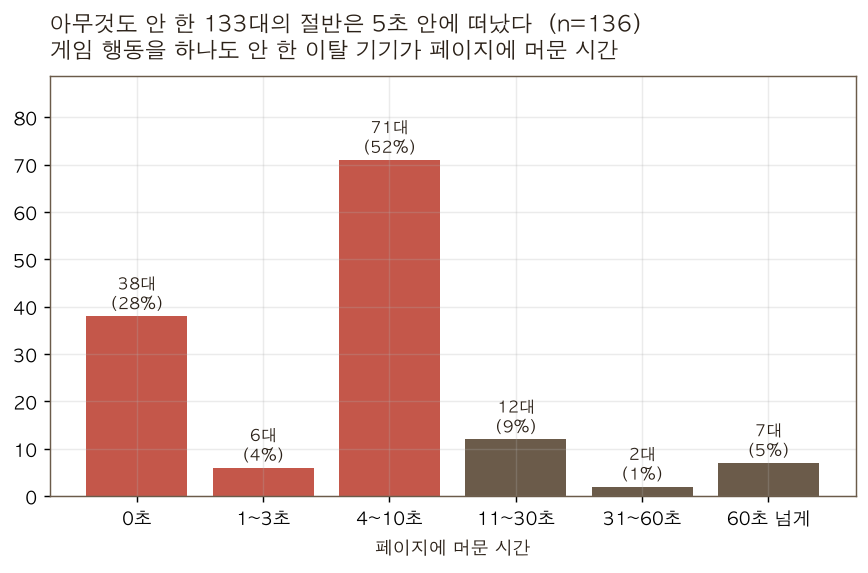

In [10]:
bins   = [-1, 0, 3, 10, 30, 60, 10**9]
labels = ["0초", "1~3초", "4~10초", "11~30초", "31~60초", "60초 넘게"]
g = pd.cut(noact.span_sec, bins=bins, labels=labels).value_counts().reindex(labels)

n = len(noact)
fig, ax = R.new("아무것도 안 한 133대의 절반은 5초 안에 떠났다", n=n,
                sub="게임 행동을 하나도 안 한 이탈 기기가 페이지에 머문 시간")
colors = [R.PALETTE[0]] * 3 + [R.MUTED] * 3
ax.bar(labels, g.values, color=colors)
ax.set_xlabel("페이지에 머문 시간")
for i, v in enumerate(g.values):
    ax.text(i, v + 1.5, f"{v}대\n({v/n:.0%})", ha="center", fontsize=9, color=R.INK)
ax.set_ylim(0, g.max() * 1.25)
R.show(R.save(fig, ax, "g_dwell_noaction"))

### 읽은 것

체류 중앙값 5초, 85%가 10초 안에 떠났다. 29%는 아예 0초다.
그중 화면을 실제로 본 시간은 중앙값 1.5초. 나머지 3.5초는 로딩이었을 공산이 크다.

1.5초는 "뭘 해야 할지 모르겠다"고 판단할 시간이 아니다.
튜토리얼 가설은 적어도 이 133대에는 안 맞는다.

**주의할 것 하나** — `scroll` 이벤트가 107대에서 찍혔다고 사람이 스크롤했다는 뜻은 아니다.
GA4 기본 측정은 페이지 90% 지점에서 자동 발화하는데, 이 게임은 전체화면 캔버스라 스크롤할 게 없다.
로드되자마자 자동으로 찍혔을 가능성이 높아서 근거로 쓰지 않았다.

## 5. 절대 수 말고 비율로

앞 차트는 133대가 다 먹어서 나머지가 안 보인다.
"그 행동까지 간 사람 중 몇 %가 거기서 멈췄나"로 바꿔 봤다.

- 분모: 그 행동을 한 번이라도 한 기기
- 분자: 그중 그 행동이 마지막이었고 안 돌아온 기기

분자가 대부분 한 자리수라 점추정만 보면 순위가 거짓말을 한다. 윌슨 신뢰구간을 같이 그렸다.

In [11]:
Q_STOP = f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name, TIMESTAMP_MICROS(event_timestamp) AS ts
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE event_name NOT IN ({EXCLUDE})
),
all_ev AS (   -- 이탈 판정은 자동 이벤트까지 포함한 '마지막 흔적' 기준
  SELECT user_pseudo_id AS device, MAX(TIMESTAMP_MICROS(event_timestamp)) AS last_seen
  FROM `calm-forest.analytics_547127440.events_*` GROUP BY 1
),
bounds AS (SELECT MAX(last_seen) AS data_end FROM all_ev),
churned AS (
  SELECT a.device FROM all_ev a, bounds b
  WHERE a.last_seen < TIMESTAMP_SUB(b.data_end, INTERVAL 3 DAY)
),
reached AS (SELECT DISTINCT device, event_name FROM ev),
last_act AS (
  SELECT device, event_name FROM (
    SELECT device, event_name,
           ROW_NUMBER() OVER (PARTITION BY device ORDER BY ts DESC) rn
    FROM ev) WHERE rn = 1
)
SELECT r.event_name AS action,
       COUNT(DISTINCT r.device) AS reached,
       COUNT(DISTINCT IF(l.device IS NOT NULL AND c.device IS NOT NULL,
                         r.device, NULL)) AS stopped_here
FROM reached r
LEFT JOIN last_act l ON l.device = r.device AND l.event_name = r.event_name
LEFT JOIN churned  c ON c.device = r.device
GROUP BY 1
"""

stop = bq.read_sql(Q_STOP)
stop["stop_rate"] = stop.stopped_here / stop.reached
print(f"액션 {len(stop)}종 · 분모 25 이상 {(stop.reached>=25).sum()}종")
stop.sort_values("stop_rate", ascending=False).head(8)

액션 96종 · 분모 25 이상 21종


,action,reached,stopped_here,stop_rate
95,traffic_source,1,1,1.0
7,login,102,33,0.323529
33,sea_catch,4,1,0.25
56,boat_hit,9,2,0.222222
9,character_change,5,1,0.2
58,zone_enter,22,4,0.181818
22,exit_farm,17,3,0.176471
50,mine_ore,12,2,0.166667


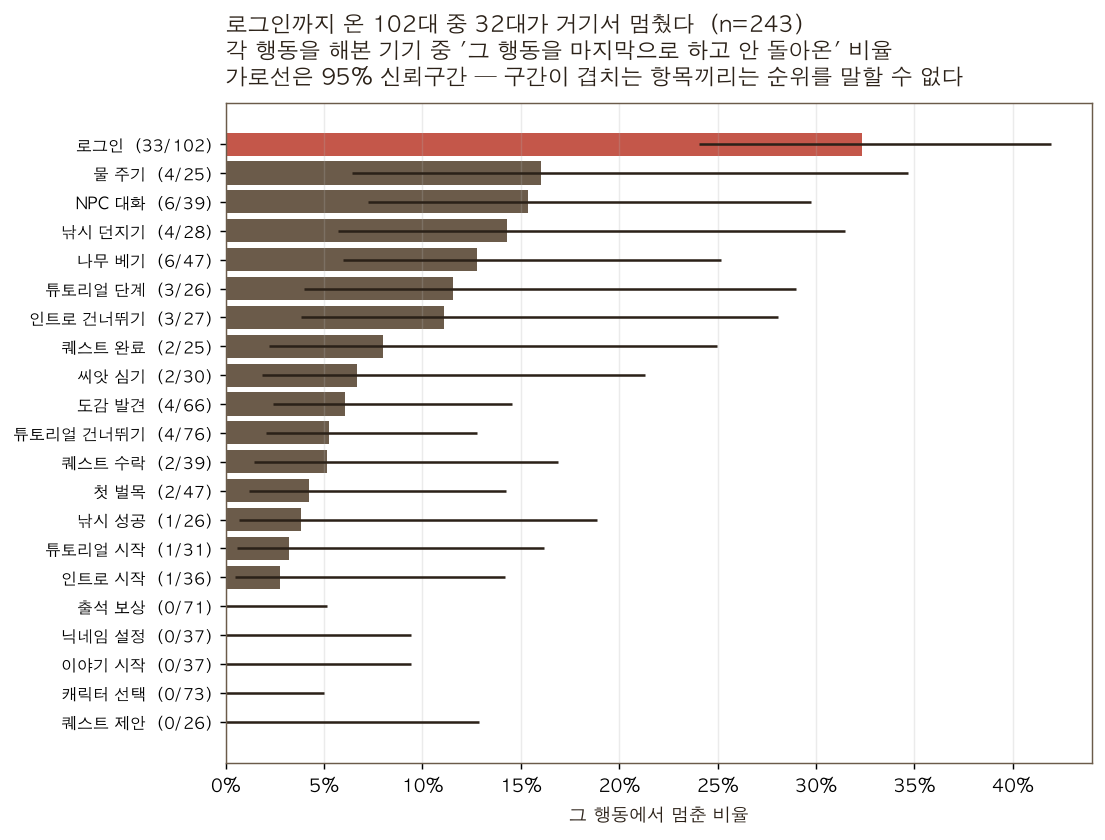

In [12]:
def wilson(k, n, z=1.96):
    """윌슨 신뢰구간. 분자가 0이거나 한 자리수일 때도 무너지지 않는다."""
    if n == 0:
        return (0.0, 0.0)
    p, d = k / n, 1 + z**2 / n
    c = (p + z**2 / (2*n)) / d
    h = z * ((p*(1-p)/n + z**2/(4*n**2)) ** 0.5) / d
    return max(0.0, c - h), min(1.0, c + h)

# 분모 25 미만은 구간이 너무 넓어 순위를 논할 수 없다
d = stop[stop.reached >= 25].copy()
d[["lo", "hi"]] = d.apply(lambda r: pd.Series(wilson(r.stopped_here, r.reached)), axis=1)
d = d.sort_values("stop_rate", ascending=False)

KO2 = {"login": "로그인", "water_crop": "물 주기", "npc_talk": "NPC 대화",
       "fishing_cast": "낚시 던지기", "chop_tree": "나무 베기",
       "tutorial_step": "튜토리얼 단계", "quest_complete": "퀘스트 완료",
       "intro_skip": "인트로 건너뛰기", "dex_discover": "도감 발견",
       "tutorial_skip": "튜토리얼 건너뛰기", "quest_accept": "퀘스트 수락",
       "first_chop": "첫 벌목", "fishing_catch": "낚시 성공", "plant_seed": "씨앗 심기",
       "tutorial_start": "튜토리얼 시작", "intro_start": "인트로 시작",
       "character_select": "캐릭터 선택", "daily_bonus": "출석 보상",
       "harvest_crop": "수확", "quest_offered": "퀘스트 제안",
       "story_chapter_start": "이야기 시작", "nickname_set": "닉네임 설정",
       "house_complete": "집 완성"}
d["label"] = d.action.map(lambda s: KO2.get(s, s)) + d.apply(
    lambda r: f"  ({r.stopped_here}/{r.reached})", axis=1)

from matplotlib.ticker import FuncFormatter
fig, ax = R.new("로그인까지 온 102대 중 32대가 거기서 멈췄다", n=243,
                sub="각 행동을 해본 기기 중 '그 행동을 마지막으로 하고 안 돌아온' 비율\n"
                    "가로선은 95% 신뢰구간 — 구간이 겹치는 항목끼리는 순위를 말할 수 없다",
                figsize=(8.6, 6.6))
y = range(len(d))
ax.barh(list(y), d.stop_rate, color=[R.PALETTE[0]] + [R.MUTED] * (len(d) - 1))
ax.hlines(list(y), d.lo, d.hi, color=R.INK, linewidth=1.4)
ax.set_yticks(list(y)); ax.set_yticklabels(d.label, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("그 행동에서 멈춘 비율")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlim(0, min(1.0, d.hi.max() * 1.05))
ax.grid(axis="y", visible=False)
R.show(R.save(fig, ax, "g_stop_rate", zero_base=False))

### 읽은 것

게임 안에는 "여기서 많이 나간다"는 지점이 없다.

로그인 31%(32/102) 하나만 도드라지고, 나머지 20종은 전부 0~16%에 분자가 0~6대다.
캐릭터 선택(0/73), 출석 보상(0/71), 닉네임 설정(0/37), 이야기 시작(0/37)은 멈춘 기기가 아예 없다.

튜토리얼 관련 셋은 중간 아래다 — 튜토리얼 단계 11.5%(3/26), 건너뛰기 5.3%(4/76), 시작 3.2%(1/31).
튜토리얼이 사람을 쫓아내고 있지는 않다.

**이 지표에는 구조적 편향이 있다.** 게임 흐름상 뒤에 있거나 자주 반복되는 행동일수록 마지막이 되기 쉽다.
`구역 진입`이나 `밭 나가기` 같은 게 위로 온 것도 그 영향으로 보인다(분모가 작아 차트에선 뺐다).

## 6. 로그인 32대 — 앞의 해석을 뒤집는다

1번 차트에서 이 32대를 "로그인만 하고 끝"으로 읽었다. **틀렸다.**

체류시간을 재보니 실제 시청시간 중앙값이 207초로 나왔다.
아무것도 안 한 사람이 3.5분을 볼 리가 없어서 뭘 했는지 다시 봤다.

In [13]:
Q_WHAT = f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name, TIMESTAMP_MICROS(event_timestamp) AS ts
  FROM `calm-forest.analytics_547127440.events_*`
),
acts AS (SELECT * FROM ev WHERE event_name NOT IN ({EXCLUDE})),
dev AS (SELECT device, MAX(ts) AS last_seen, MIN(ts) AS first_seen FROM ev GROUP BY 1),
bounds AS (SELECT MAX(last_seen) AS data_end FROM dev),
churned AS (SELECT d.device FROM dev d, bounds b
            WHERE d.last_seen < TIMESTAMP_SUB(b.data_end, INTERVAL 3 DAY)),
last_act AS (
  SELECT device, event_name FROM (
    SELECT device, event_name, ROW_NUMBER() OVER (PARTITION BY device ORDER BY ts DESC) rn
    FROM acts) WHERE rn = 1),
cohort AS (
  SELECT c.device FROM churned c JOIN last_act l USING (device)
  WHERE l.event_name = 'login')
SELECT a.device,
       COUNT(DISTINCT a.event_name) AS kinds,
       COUNT(*)                     AS acts
FROM cohort JOIN acts a USING (device)
GROUP BY 1 ORDER BY kinds DESC
"""

what = bq.read_sql(Q_WHAT)
print("로그인 말고 아무 행동도 안 한 기기:", int((what.kinds == 1).sum()), "/", len(what))
print("행동 종류 수 중앙값:", int(what.kinds.median()), "· 최대:", int(what.kinds.max()))
what.head(5)

로그인 말고 아무 행동도 안 한 기기: 0 / 33
행동 종류 수 중앙값: 6 · 최대: 24


,device,kinds,acts
0,852795036.1786509729,24,462
1,1452327877.1788145601,23,61
2,1997761602.1787017056,19,141
3,1063089945.1785083844,18,258
4,647817203.1786963136,15,101


### 정정

32대 전부가 다른 행동을 했다. 로그인만 한 기기는 **0대**다.
행동 종류 중앙값 5~6종, 많은 기기는 24종에 462번까지 찍혔다. 카페·요리·낚시·배를 다 해본 유저다.

원인은 `login`이 **재방문할 때 페이지 로드마다 자동으로 찍히는 이벤트**라서다.
그래서 "마지막 행동 = 로그인"은 로그인에서 막혔다는 뜻이 아니라,
**마지막으로 한 번 더 들어왔다가 아무것도 안 하고 떠났다**는 뜻이다.

앞의 두 가지를 취소한다.

- 1번 차트의 `로그인만 하고 끝` 라벨
- "로그인 직후 진도가 안 나감"이라는 해석

다만 이건 데이터 패턴에서 추론한 것이다. `js/analytics.js`를 읽어 확정하지는 않았다.

In [14]:
Q_AFTER = f"""
WITH ev AS (
  SELECT user_pseudo_id AS device, event_name, TIMESTAMP_MICROS(event_timestamp) AS ts,
         (SELECT value.int_value FROM UNNEST(event_params)
          WHERE key = 'engagement_time_msec') AS eng_ms
  FROM `calm-forest.analytics_547127440.events_*`
),
acts AS (SELECT * FROM ev WHERE event_name NOT IN ({EXCLUDE})),
dev AS (SELECT device, MAX(ts) AS last_seen, MIN(ts) AS first_seen FROM ev GROUP BY 1),
bounds AS (SELECT MAX(last_seen) AS data_end FROM dev),
churned AS (SELECT d.device FROM dev d, bounds b
            WHERE d.last_seen < TIMESTAMP_SUB(b.data_end, INTERVAL 3 DAY)),
last_act AS (
  SELECT device, event_name FROM (
    SELECT device, event_name, ROW_NUMBER() OVER (PARTITION BY device ORDER BY ts DESC) rn
    FROM acts) WHERE rn = 1),
cohort AS (
  SELECT c.device FROM churned c JOIN last_act l USING (device)
  WHERE l.event_name = 'login')
SELECT d.device,
       -- 마지막 로그인 → 마지막 흔적 = 그 사람의 '마지막 방문' 길이
       TIMESTAMP_DIFF(d.last_seen, MAX(a.ts), SECOND) AS after_login_sec
FROM cohort JOIN dev d USING (device)
JOIN acts a ON a.device = d.device AND a.event_name = 'login'
GROUP BY d.device, d.last_seen
"""

after = bq.read_sql(Q_AFTER)
print(f"중앙값 {after.after_login_sec.median():.0f}초 · "
      f"10초 이내 {int((after.after_login_sec<=10).sum())}대 · "
      f"60초 이내 {int((after.after_login_sec<=60).sum())}대")

중앙값 10초 · 10초 이내 17대 · 60초 이내 21대


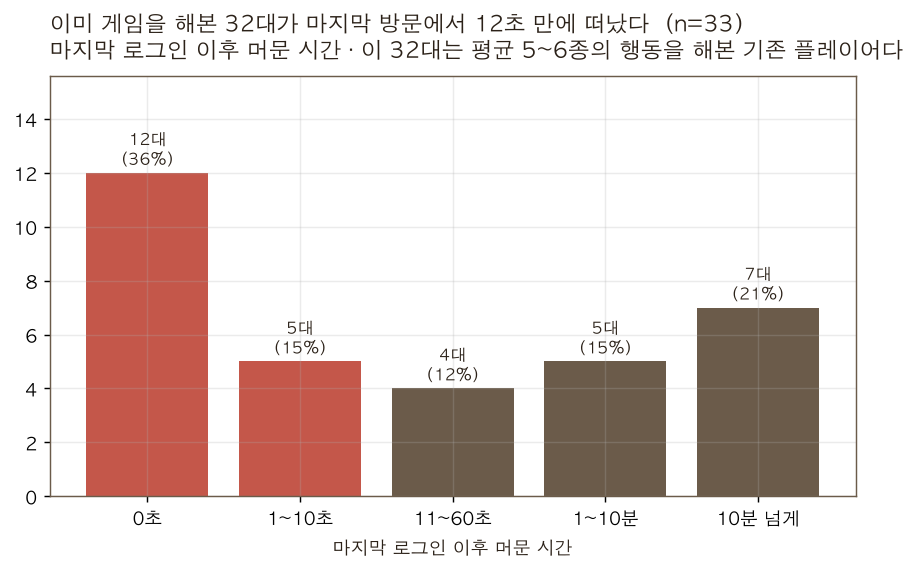

In [15]:
bins2   = [-1, 0, 10, 60, 600, 10**9]
labels2 = ["0초", "1~10초", "11~60초", "1~10분", "10분 넘게"]
g2 = pd.cut(after.after_login_sec, bins=bins2, labels=labels2).value_counts().reindex(labels2)

n2 = len(after)
fig, ax = R.new("이미 게임을 해본 32대가 마지막 방문에서 12초 만에 떠났다", n=n2,
                sub="마지막 로그인 이후 머문 시간 · 이 32대는 평균 5~6종의 행동을 해본 기존 플레이어다")
ax.bar(labels2, g2.values, color=[R.PALETTE[0]] * 2 + [R.MUTED] * 3)
ax.set_xlabel("마지막 로그인 이후 머문 시간")
for i, v in enumerate(g2.values):
    ax.text(i, v + 0.3, f"{v}대\n({v/n2:.0%})", ha="center", fontsize=9, color=R.INK)
ax.set_ylim(0, g2.max() * 1.3)
R.show(R.save(fig, ax, "g_login32_dwell"))

### 읽은 것

절반은 12초 안에 떠났고, 34%는 0초다. 그런데 22%(7대)는 10분 넘게 아무것도 안 하고 있었다.
하나로 안 묶인다.

133대와는 성격이 다르다.

| | 133대 | 32대 |
|---|---|---|
| 정체 | 게임을 한 번도 안 해본 기기 | 이미 플레이한 기존 유저(행동 5~6종) |
| 이탈 시점 | 첫 방문, 5초 | 마지막 재방문, 12초 |
| 성격 | 들어오지 못함 | 들어왔다 나감 |

## 7. 나가기 직전에 무엇을 하고 있었나

앞 절들은 "어디서 멈췄나"를 활동 이름으로 봤다. 이번엔 **떠나기 직전의 움직임**을 본다.
조용히 멈췄다 나가는지, 하던 중에 뚝 끊는지는 대응이 완전히 다르다.

GA4 이벤트 공백으로는 못 잰다 — 걷거나 둘러보는 건 이벤트를 안 만들기 때문이다.
대신 `game_logs` 의 좌표를 쓴다. **직전 행과 좌표가 같으면 하트비트 = 안 움직인 것**이다.
이 판정은 행 수 기반이라 `created_at` 이 배치 삽입 시각인 문제([logger.js](../js/logger.js))의 영향을 안 받는다.

In [16]:
idle = bq.read_sql("""
WITH r AS (
  SELECT session_id, id,
         ROW_NUMBER() OVER w AS rn,
         COUNT(*) OVER (PARTITION BY session_id) AS pts,
         CAST(char_x = LAG(char_x) OVER w AND char_z = LAG(char_z) OVER w AS INT64) AS idle
  FROM `calm-forest.calm_forest_raw.game_logs`
  WHERE client_id IS NOT NULL
  WINDOW w AS (PARTITION BY session_id ORDER BY id)
)
SELECT session_id,
       AVG(IF(rn <= pts - 10, idle, NULL)) AS idle_early,
       AVG(IF(rn >  pts - 10, idle, NULL)) AS idle_last10
FROM r WHERE pts >= 30 GROUP BY 1
""")
print(f"세션 {len(idle)}개 (좌표 30행 이상)")
print(f"앞부분 정지비율 {idle.idle_early.mean():.1%} → 마지막 10행 {idle.idle_last10.mean():.1%}")
print(f"끝이 더 정지한 세션 {int((idle.idle_last10 > idle.idle_early).sum())}개 "
      f"({(idle.idle_last10 > idle.idle_early).mean():.0%})")

세션 361개 (좌표 30행 이상)
앞부분 정지비율 30.9% → 마지막 10행 53.5%
끝이 더 정지한 세션 234개 (65%)


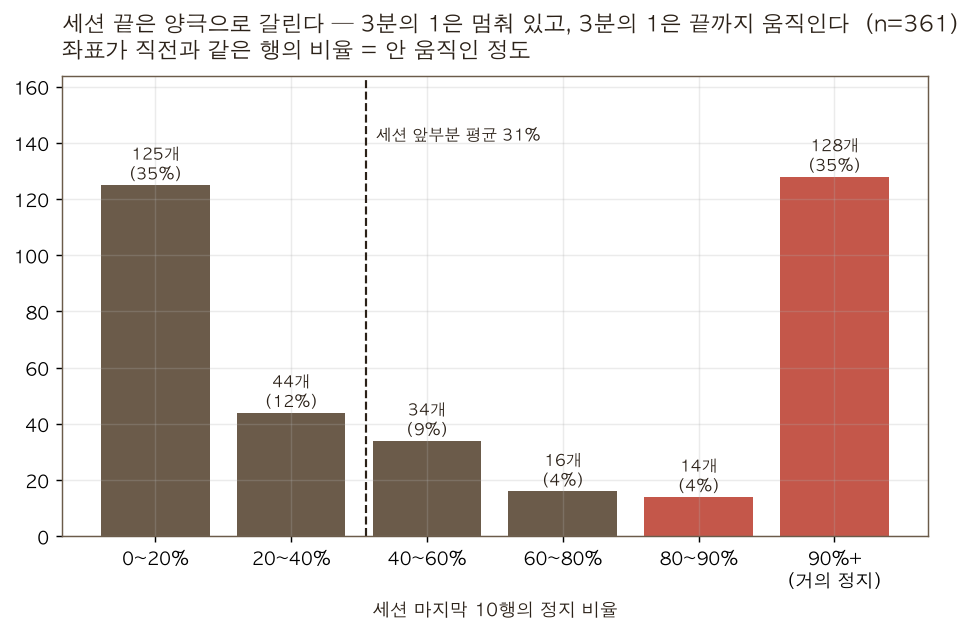

In [17]:
bins   = [-0.01, 0.2, 0.4, 0.6, 0.8, 0.9, 1.01]
labels = ["0~20%", "20~40%", "40~60%", "60~80%", "80~90%", "90%+\n(거의 정지)"]
g = pd.cut(idle.idle_last10, bins=bins, labels=labels).value_counts().reindex(labels)

n = len(idle)
fig, ax = R.new("세션 끝은 양극으로 갈린다 — 3분의 1은 멈춰 있고, 3분의 1은 끝까지 움직인다", n=n,
                sub="좌표가 직전과 같은 행의 비율 = 안 움직인 정도",
                figsize=(8.6, 4.6))
ax.bar(labels, g.values, color=[R.MUTED]*4 + [R.PALETTE[0]]*2)
ax.set_xlabel("세션 마지막 10행의 정지 비율")
for i, v in enumerate(g.values):
    ax.text(i, v + 2, f"{v}개\n({v/n:.0%})", ha="center", fontsize=9, color=R.INK)
ax.set_ylim(0, g.max() * 1.28)
ax.axvline(1.55, color=R.INK, ls="--", lw=1.2)
ax.text(1.62, g.max() * 1.1, "세션 앞부분 평균 31%", fontsize=9, color=R.INK)
R.show(R.save(fig, ax, "g_idle_before_exit"))

### 방치가 아니라 멈칫이다

"켜놓고 아예 안 한다"인지 보려면 **정지가 얼마나 길게 이어졌는지**를 재야 한다.
마지막 10행만 봐서는 알 수 없다.

In [18]:
tail = bq.read_sql("""
WITH r AS (
  SELECT session_id, id,
         ROW_NUMBER() OVER w AS rn,
         COUNT(*) OVER (PARTITION BY session_id) AS pts,
         CAST(char_x = LAG(char_x) OVER w AND char_z = LAG(char_z) OVER w AS INT64) AS idle
  FROM `calm-forest.calm_forest_raw.game_logs`
  WHERE client_id IS NOT NULL
  WINDOW w AS (PARTITION BY session_id ORDER BY id)
),
f AS (
  SELECT session_id, pts, rn, idle,
         MAX(IF(idle = 0, rn, NULL)) OVER (PARTITION BY session_id) AS last_move_rn
  FROM r WHERE pts >= 30
)
SELECT session_id, ANY_VALUE(pts) AS pts,
       ANY_VALUE(pts - COALESCE(last_move_rn, 0)) AS tail_idle_rows
FROM f GROUP BY session_id
""")
q = tail.tail_idle_rows
print(f"끝 연속 정지 행 수 — 중앙값 {q.median():.0f} · 75% {q.quantile(.75):.0f} · 최대 {q.max():.0f}")
for lab, m in [("10행 이하(≈1분 이하)", q <= 10), ("11~50행", (q > 10) & (q <= 50)),
               ("51~200행", (q > 50) & (q <= 200)), ("200행 초과(≈27분+)", q > 200)]:
    print(f"  {lab:22s} {int(m.sum()):>4d}개 ({m.mean():.0%})")

끝 연속 정지 행 수 — 중앙값 4 · 75% 15 · 최대 317
  10행 이하(≈1분 이하)          240개 (66%)
  11~50행                  106개 (29%)
  51~200행                  12개 (3%)
  200행 초과(≈27분+)            3개 (1%)


**중앙값 4행.** 하트비트가 8초 간격이니 대략 **30초 남짓 멈췄다가 창을 닫는다.**
27분 넘게 켜둔 세션은 3개(1%)뿐이다.

켜놓고 방치하는 그림이 아니라, **잠깐 멈칫하다 나가는** 그림이다.

### 캐릭터가 멈춘 자리

그만둘 때 캐릭터가 서 있던 곳을 본다. 게임이 공간마다 원점을 멀리 띄워놨으므로
(바다 400,0 · 강 0,-400 · 카페 0,320 …) 가장 가까운 원점으로 씬을 판정한 뒤 마지막 좌표를 본다.

⚠️ **비교군 없이 보면 안 된다.** 마을은 모든 곳으로 가는 길목이라 사람이 원래 제일 오래 머문다.
멈춘 세션만 보고 "마을이 80%" 라고 하면 "사람이 마을에 많다" 를 다시 말하는 것에 지나지 않는다.
그래서 **정지로 끝난 세션과 움직이다 끝난 세션을 나란히** 놓는다.

In [19]:
place = bq.read_sql("""
WITH r AS (
  SELECT session_id, id, char_x, char_z,
         ROW_NUMBER() OVER w AS rn,
         COUNT(*) OVER (PARTITION BY session_id) AS pts,
         CAST(char_x = LAG(char_x) OVER w AND char_z = LAG(char_z) OVER w AS INT64) AS idle
  FROM `calm-forest.calm_forest_raw.game_logs`
  WHERE client_id IS NOT NULL
  WINDOW w AS (PARTITION BY session_id ORDER BY id)
),
s AS (SELECT session_id, ANY_VALUE(pts) AS pts,
             AVG(IF(rn > pts - 10, idle, NULL)) AS idle_last10
      FROM r WHERE pts >= 30 GROUP BY 1),
lastpos AS (SELECT r.session_id, r.char_x, r.char_z
            FROM r JOIN s USING (session_id) WHERE r.rn = r.pts),
-- CTE 이름을 컬럼명과 다르게 둔다. 같으면 GROUP BY 가 구조체 전체로 묶인다(실측)
tagged AS (
  SELECT l.session_id, s.idle_last10 >= 0.9 AS ended_still,
    CASE
      WHEN POW(char_x-400,2)+POW(char_z,2) < 90000 THEN '바다'
      WHEN POW(char_x,2)+POW(char_z+400,2) < 90000 THEN '강'
      WHEN POW(char_x,2)+POW(char_z-320,2) < 3600  THEN '카페'
      WHEN POW(char_x,2)+POW(char_z-250,2) < 3600  THEN '광산'
      WHEN char_z > 60                             THEN '마을 북쪽'
      ELSE '마을' END AS place
  FROM lastpos l JOIN s USING (session_id)
)
SELECT place, COUNTIF(ended_still) AS still_n, COUNTIF(NOT ended_still) AS moving_n
FROM tagged GROUP BY place ORDER BY still_n + moving_n DESC
""")
place["still_pct"]  = place.still_n  / place.still_n.sum()
place["moving_pct"] = place.moving_n / place.moving_n.sum()
place["diff_pp"]    = (place.still_pct - place.moving_pct) * 100
print(f"정지로 끝난 {place.still_n.sum()}개 vs 움직이다 끝난 {place.moving_n.sum()}개")
print(place[["place","still_n","moving_n","still_pct","moving_pct","diff_pp"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

정지로 끝난 128개 vs 움직이다 끝난 233개
place  still_n  moving_n  still_pct  moving_pct  diff_pp
   마을      102       180      0.797       0.773    2.434
    강        7        24      0.055       0.103   -4.832
   바다        7        13      0.055       0.056   -0.111
   카페        6         8      0.047       0.034    1.254
   광산        2         6      0.016       0.026   -1.013
마을 북쪽        4         2      0.031       0.009    2.267


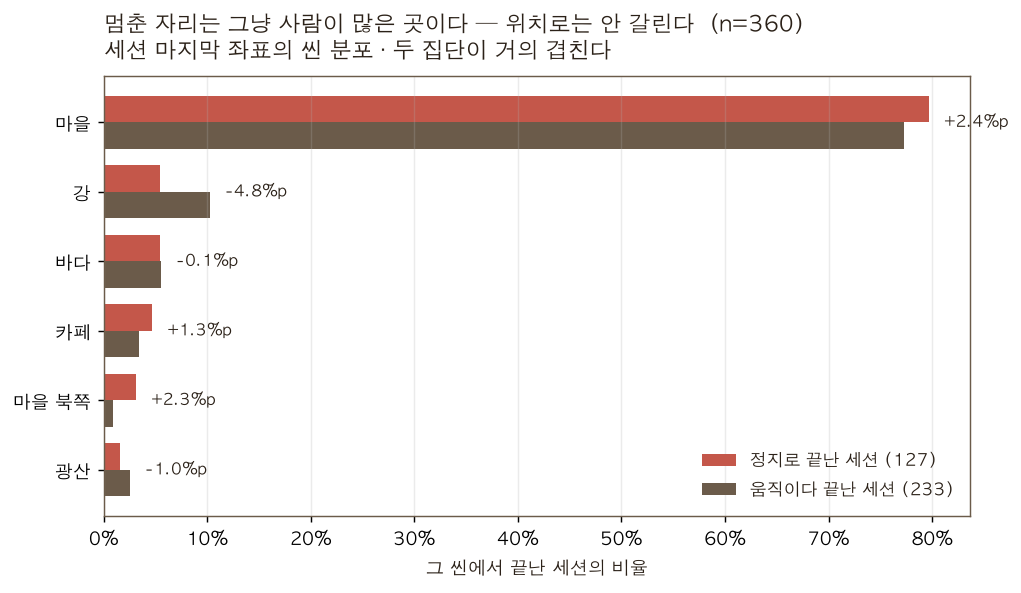

In [20]:
import numpy as np

d = place.sort_values("still_n", ascending=False)
y = np.arange(len(d)); h = 0.38
fig, ax = R.new("멈춘 자리는 그냥 사람이 많은 곳이다 — 위치로는 안 갈린다", n=360,
                sub="세션 마지막 좌표의 씬 분포 · 두 집단이 거의 겹친다",
                figsize=(8.6, 4.4))
ax.barh(y - h/2, d.still_pct,  height=h, color=R.PALETTE[0], label="정지로 끝난 세션 (127)")
ax.barh(y + h/2, d.moving_pct, height=h, color=R.MUTED,      label="움직이다 끝난 세션 (233)")
ax.set_yticks(y); ax.set_yticklabels(d.place, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("그 씬에서 끝난 세션의 비율")
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right", fontsize=9.5)
for i, r in enumerate(d.itertuples()):
    ax.text(max(r.still_pct, r.moving_pct) + 0.015, i,
            f"{r.diff_pp:+.1f}%p", va="center", fontsize=9, color=R.INK)
R.show(R.save(fig, ax, "g_still_place", zero_base=False))

### 읽은 것 — 발견 없음

마을이 정지 80.3% · 움직임 77.3% 로 **차이가 3.1%p 밖에 안 난다.** 나머지도 마찬가지다.
강만 −5.6%p 로 눈에 띄지만 6대 vs 24대라 노이즈 범위다.

**위치로는 멈춤을 못 가린다.** 이 절을 지우지 않고 남기는 이유는, 나중에 같은 걸 다시 돌리지 않게 하기 위해서다.

처음엔 "멈추는 자리는 콘텐츠 안이 아니라 마을 한복판" 이라고 적었었다.
멈춘 세션만 보고 비교군을 안 놓은 탓이다. 기저율을 나누자 남는 게 없었다.

### 이 숫자로 말할 수 없는 것

- **정지 ≠ 지루함이다.** 모달을 읽는 중이거나 미니게임 중일 수 있다.
- **요리·조각 무대는 좌표를 안 남긴다.** 그래서 요리 중인 사람이 '완전 정지' 로 잡힌다.
  좌표를 새로 만들 게 아니라 `cooking_start`~`cooking_result` 구간을 계산에서 빼야 한다
  (요리 7대·조각 1대라 지금은 영향이 작다).
- **(0,0) 19개는 계측 잡음일 수 있다.** 로드 직후 기본값일 가능성이 있다.
- **마을이 많은 건 당연할 수 있다.** 모든 곳으로 가는 길목이라 체류가 길다. 체류 대비로 정규화해야 비교가 된다.
- **행 수를 초로 옮긴 건 근사다.** 하트비트 8초 간격을 가정한 값이고, `created_at` 이
  배치 삽입 시각이라 실제 간격은 못 잰다. 그래서 "몇 초 멈추면" 같은 임계값은 이 데이터로 못 정한다.
- **마지막 행 이후는 안 보인다.** 창을 닫기 전 더 멈춰 있었어도 로그가 없다 → 이 값은 하한이다.
- `game_logs` 기준이라 게스트만이 아니라 로그인 유저가 섞여 있다.

## 남는 것

### 이탈은 세 덩어리다

| 구간 | 규모 | 성격 |
|---|---|---|
| 페이지 로딩 | 133대 | 화면을 볼 시간도 없이 나감(중앙값 5초, 실제 시청 1.5초) |
| 재방문 후 무행동 | 32대 | 기존 유저가 다시 왔다가 12초 만에 나감 |
| 게임 안 | 65대 | 20여 종에 흩어짐, 특정 지점 없음 |

### 처음 세운 가설은 어떻게 됐나

"튜토리얼 안내를 못 보고 뭘 해야 할지 몰라서 나간다."

133대에는 안 맞는다. 화면을 볼 시간 자체가 없었다.
32대에는 맞을 여지가 있지만 튜토리얼 이야기는 아니다.
이미 게임을 아는 사람들이라 튜토리얼로 건드릴 수 있는 부분이 아니다.

### 이 숫자로 말할 수 없는 것

- **왜 나갔는지는 없다.** 로딩이 느렸는지, 3D가 안 뜨는 기기였는지, 잘못 들어온 트래픽인지 안 갈린다. 셋은 대응이 전혀 다르다.
- **봇 여부를 안 갈랐다.** 체류 0초 38대는 크롤러일 수 있다.
- **`engaged_sec`이 133대 중 52대(39%)에서 결측**이다. 너무 빨리 나가 측정이 안 붙은 것으로 보이는데, 그렇다면 실제 중앙값은 1.5초보다 더 낮다.
- **`login`이 자동 발화라는 건 추론이다.** 코드로 확인하지 않았다.
- **3일 무복귀를 이탈로 봤다.** 기준을 바꾸면 숫자가 움직인다.
- **10분 넘게 머문 7대가 설명이 안 된다.** 탭 방치인지 뭔가 막힌 건지 모른다.
- 32대짜리 차트는 막대마다 4~11대다. 비율이 크게 흔들린다.

### 다음에 볼 수 있는 것

정하지 않고 적어만 둔다.

1. 133대의 유입 경로 — 캠페인·referrer별로 갈리는지
2. 133대의 기기·브라우저 분포 — 특정 환경에서만 안 뜨는지
3. `js/analytics.js`를 읽어 `login` 발화 시점 확정
4. 32대가 마지막 방문 직전에 뭘 하다 멈췄는지 — 콘텐츠 소진인지 확인